In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("naukri_com-job_sample.csv")

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 22000
Number of columns: 14
Dataset shape: (22000, 14)


In [4]:
df = df.head(8000)

print(df.shape)

(8000, 14)


In [5]:
df.to_csv("raw_jobs.csv", index=False)

In [6]:
print(df.columns)
print(df.columns.to_list())

Index(['company', 'education', 'experience', 'industry', 'jobdescription',
       'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions',
       'payrate', 'postdate', 'site_name', 'skills', 'uniq_id'],
      dtype='str')
['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id']


In [7]:
print(df.head(10))

                                             company  \
0                                   MM Media Pvt Ltd   
1                                 find live infotech   
2                Softtech Career Infosystem Pvt. Ltd   
3                             Onboard HRServices LLP   
4         Spire Technologies and Solutions Pvt. Ltd.   
5                    PFS Web Global Services Pvt Ltd   
6             Kinesis Management Consultant Pvt. Ltd   
7  Agile HR consultancy Pvt. Ltd. hiring for Ross...   
8                  HANSUM INDIA ELECTRONICS PVT.LTD.   
9                                          Accenture   

                                           education   experience  \
0  UG: B.Tech/B.E. - Any Specialization PG:Any Po...    0 - 1 yrs   
1  UG: B.Tech/B.E. - Any Specialization PG:MBA/PG...    0 - 0 yrs   
2  UG: Any Graduate - Any Specialization PG:Any P...    4 - 8 yrs   
3  UG: Any Graduate - Any Specialization PG:CA Do...  11 - 15 yrs   
4  UG: B.Tech/B.E. - Any Specializatio

In [8]:
print(df.head())

                                      company  \
0                            MM Media Pvt Ltd   
1                          find live infotech   
2         Softtech Career Infosystem Pvt. Ltd   
3                      Onboard HRServices LLP   
4  Spire Technologies and Solutions Pvt. Ltd.   

                                           education   experience  \
0  UG: B.Tech/B.E. - Any Specialization PG:Any Po...    0 - 1 yrs   
1  UG: B.Tech/B.E. - Any Specialization PG:MBA/PG...    0 - 0 yrs   
2  UG: Any Graduate - Any Specialization PG:Any P...    4 - 8 yrs   
3  UG: Any Graduate - Any Specialization PG:CA Do...  11 - 15 yrs   
4  UG: B.Tech/B.E. - Any Specialization PG:Any Po...    6 - 8 yrs   

                                   industry  \
0          Media / Entertainment / Internet   
1  Advertising / PR / MR / Event Management   
2           IT-Software / Software Services   
3    Banking / Financial Services / Broking   
4           IT-Software / Software Services   

       

In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              7996 non-null   str    
 1   education            7503 non-null   str    
 2   experience           7996 non-null   str    
 3   industry             7996 non-null   str    
 4   jobdescription       7996 non-null   str    
 5   jobid                8000 non-null   int64  
 6   joblocation_address  7996 non-null   str    
 7   jobtitle             8000 non-null   str    
 8   numberofpositions    1988 non-null   float64
 9   payrate              7974 non-null   str    
 10  postdate             7987 non-null   str    
 11  site_name            0 non-null      str    
 12  skills               7771 non-null   str    
 13  uniq_id              8000 non-null   str    
dtypes: float64(1), int64(1), str(12)
memory usage: 875.1 KB
None


In [10]:
missing_values = df.isnull().sum()

print(missing_values)

company                   4
education               497
experience                4
industry                  4
jobdescription            4
jobid                     0
joblocation_address       4
jobtitle                  0
numberofpositions      6012
payrate                  26
postdate                 13
site_name              8000
skills                  229
uniq_id                   0
dtype: int64


In [11]:
missing_analysis = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_analysis

,Missing Count,Missing Percentage
company,4,0.0500
education,497,6.2125
experience,4,0.0500
industry,4,0.0500
jobdescription,4,0.0500
jobid,0,0.0000
joblocation_address,4,0.0500
jobtitle,0,0.0000
numberofpositions,6012,75.1500
payrate,26,0.3250


In [12]:
duplicate_count = df.duplicated().sum()
print("Duplicate records :", duplicate_count)

Duplicate records : 0


In [13]:
duplicate_job_ids = df["jobid"].duplicated().sum()

print("Duplicate job IDs:", duplicate_job_ids)

Duplicate job IDs: 2


In [14]:
print(df["jobdescription"].head())

0    Job Description   Send me Jobs like this Quali...
1    Job Description   Send me Jobs like this Quali...
2    Job Description   Send me Jobs like this - as ...
3    Job Description   Send me Jobs like this - Inv...
4    Job Description   Send me Jobs like this Pleas...
Name: jobdescription, dtype: str


In [15]:
print("Missing job descriptions:",
      df["jobdescription"].isnull().sum())

Missing job descriptions: 4


In [16]:
df["description_length"] = (
    df["jobdescription"]
    .fillna("")
    .str.len()
)
print(df["description_length"].describe())

count     8000.000000
mean      1906.840125
std       1249.388369
min          0.000000
25%       1095.000000
50%       1516.000000
75%       2361.250000
max      22089.000000
Name: description_length, dtype: float64


In [17]:
short_descriptions = df[
    df["description_length"] < 50
]

print(short_descriptions[
    ["jobtitle", "jobdescription"]
].head(10))

                                        jobtitle jobdescription
3768    1-50 of 680 Service Desk Jobs in Chennai            NaN
4026  1-50 of 658 .net Developer Jobs in Chennai            NaN
4389         1-50 of 574 Asp.net Jobs in Chennai            NaN
4841    1-50 of 507 Risk Analyst Jobs in Chennai            NaN


In [18]:
relevant_columns = {
    "job_id": "jobid",
    "job_title": "jobtitle",
    "company": "company",
    "location": "joblocation_address",
    "job_description": "jobdescription",
    "experience": "experience",
    "education": "education",
    "salary": "payrate",
    "skills": "skills"
}

for project_column, dataset_column in relevant_columns.items():
    if dataset_column in df.columns:
        print(f"✅ {project_column} → {dataset_column}")
    else:
        print(f"❌ {project_column} → Not available")

✅ job_id → jobid
✅ job_title → jobtitle
✅ company → company
✅ location → joblocation_address
✅ job_description → jobdescription
✅ experience → experience
✅ education → education
✅ salary → payrate
✅ skills → skills


In [19]:
df["text_length"] = df["jobdescription"].fillna("").str.len()

print(df[["jobdescription", "text_length"]].head())

print(df["text_length"].describe())

                                      jobdescription  text_length
0  Job Description   Send me Jobs like this Quali...         1923
1  Job Description   Send me Jobs like this Quali...         1476
2  Job Description   Send me Jobs like this - as ...         1864
3  Job Description   Send me Jobs like this - Inv...         2800
4  Job Description   Send me Jobs like this Pleas...         3085
count     8000.000000
mean      1906.840125
std       1249.388369
min          0.000000
25%       1095.000000
50%       1516.000000
75%       2361.250000
max      22089.000000
Name: text_length, dtype: float64


# Exploratory Data Analysis 


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df= pd.read_csv('raw_jobs.csv')
print("Dataset loaded successfully")

Dataset loaded successfully


In [22]:
print("Number of jobs:", len(df))

Number of jobs: 8000


In [23]:
unique_title = df["jobtitle"].nunique()
print("Number of unique job title:", unique_title)

Number of unique job title: 6852


In [24]:
top_titles = df["jobtitle"].value_counts().head(10)
print(top_titles)

jobtitle
Software Engineer                 38
Business Development Executive    36
Business Development Manager      30
Android Developer                 28
Project Manager                   23
Senior Software Engineer          22
Sales Executive                   21
Java Developer                    20
Business Analyst                  15
Marketing Executive               13
Name: count, dtype: int64


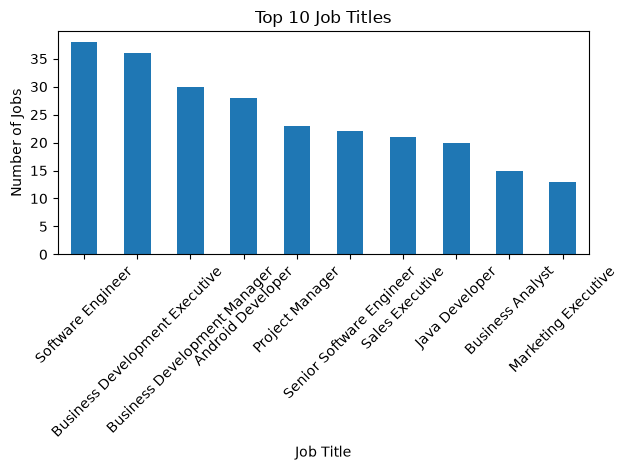

In [25]:
top_titles = df["jobtitle"].value_counts().head(10)
plt.Figure(figsize=(10,6))
top_titles.plot(kind="bar")
plt.title("Top 10 Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
top_locations = df["joblocation_address"].value_counts().head(10)
print(top_locations)

joblocation_address
Hyderabad / Secunderabad                                    1217
Bengaluru                                                   1186
Bengaluru/Bangalore                                         1128
Chennai                                                     1081
Bengaluru/Bangalore , Bengaluru / Bangalore                  360
Gurgaon                                                      169
Noida                                                        168
Delhi                                                        132
Delhi/NCR(National Capital Region)                           113
Bengaluru/Bangalore , Chennai , Hyderabad / Secunderabad      89
Name: count, dtype: int64


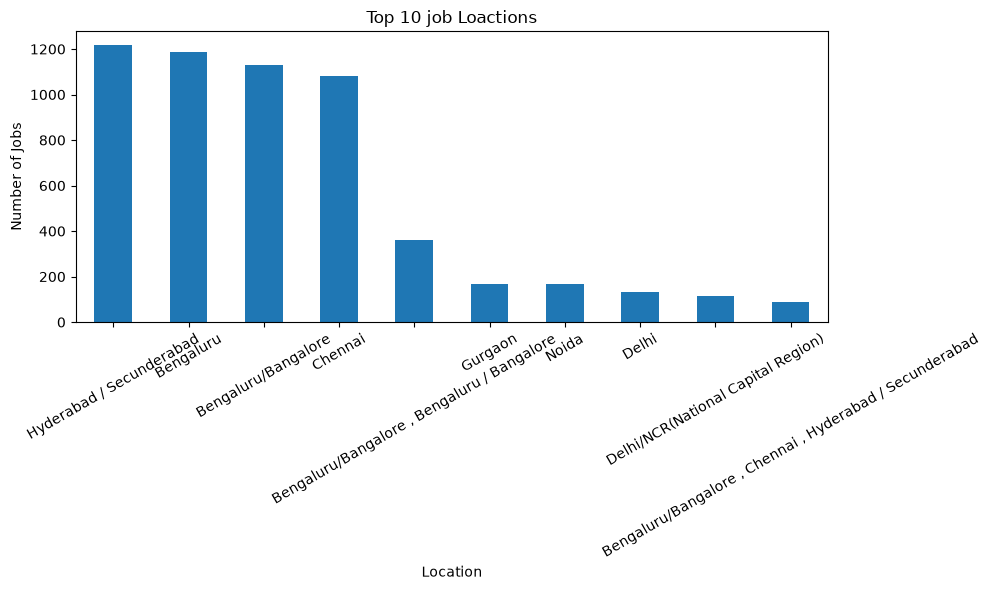

In [27]:
plt.figure(figsize=(10,6))
top_locations.plot(kind="bar")
plt.title("Top 10 job Loactions")
plt.xlabel("Location")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [28]:
df["description_length"]=(df["jobdescription"].fillna("").str.len())
print(df["description_length"].describe())

count     8000.000000
mean      1906.840125
std       1249.388369
min          0.000000
25%       1095.000000
50%       1516.000000
75%       2361.250000
max      22089.000000
Name: description_length, dtype: float64


In [29]:
print("Average description length:",
      df["description_length"].mean())

print("Minimum description length:",df["description_length"].min())

print("maximum description length:",df["description_length"].max())


Average description length: 1906.840125
Minimum description length: 0
maximum description length: 22089


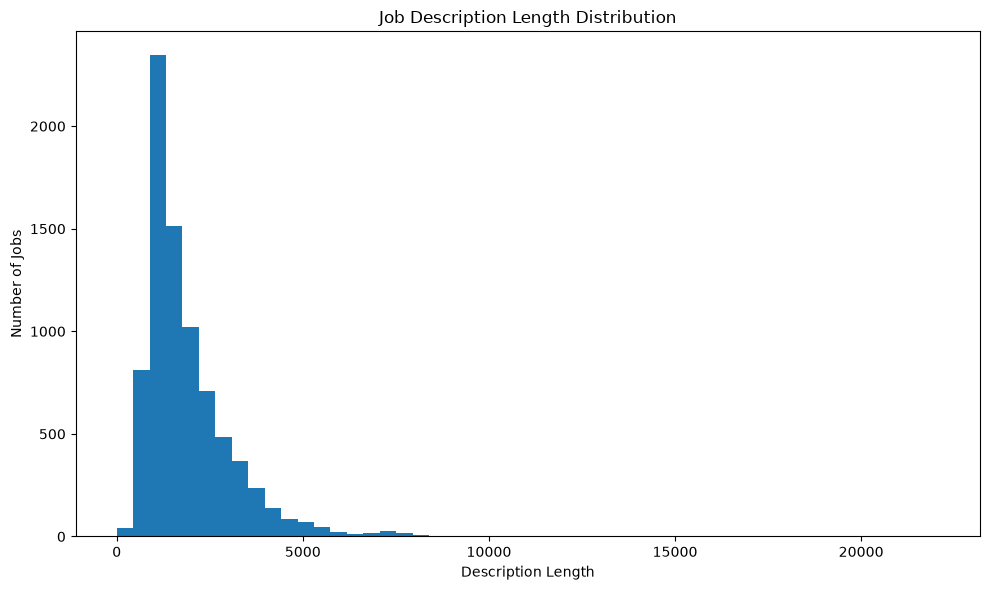

In [30]:
plt.figure(figsize=(10, 6))

plt.hist(df["description_length"], bins=50)

plt.title("Job Description Length Distribution")
plt.xlabel("Description Length")
plt.ylabel("Number of Jobs")

plt.tight_layout()
plt.show()


In [31]:
missing_values = df.isnull().sum()
print(missing_values)

company                   4
education               497
experience                4
industry                  4
jobdescription            4
jobid                     0
joblocation_address       4
jobtitle                  0
numberofpositions      6012
payrate                  26
postdate                 13
site_name              8000
skills                  229
uniq_id                   0
description_length        0
dtype: int64


In [32]:
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

missing_table

,Missing Count,Missing Percentage
company,4,0.0500
education,497,6.2125
experience,4,0.0500
industry,4,0.0500
jobdescription,4,0.0500
jobid,0,0.0000
joblocation_address,4,0.0500
jobtitle,0,0.0000
numberofpositions,6012,75.1500
payrate,26,0.3250


In [33]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)

company                   4
education               497
experience                4
industry                  4
jobdescription            4
joblocation_address       4
numberofpositions      6012
payrate                  26
postdate                 13
site_name              8000
skills                  229
dtype: int64


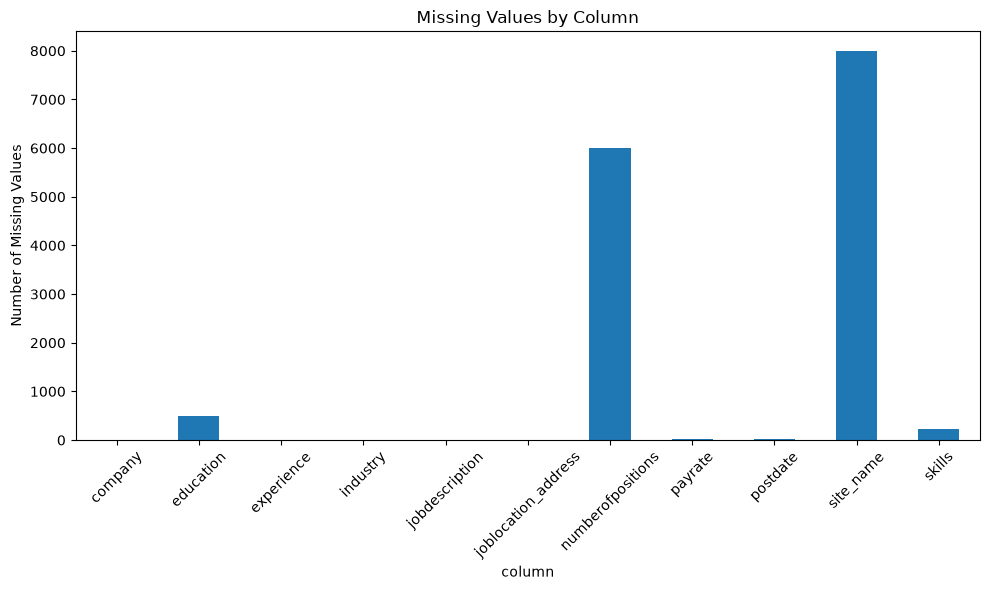

In [34]:
plt.figure(figsize=(10,6))
missing.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
duplicate_count =df.duplicated().sum()
print("Duplicate records:", duplicate_count)

Duplicate records: 0


In [36]:
duplicate_percentage = (
    duplicate_count / len(df)
) * 100

print("Duplicate percentage:", duplicate_percentage)

Duplicate percentage: 0.0


In [37]:
top_companies = df["company"].value_counts().head(10)
print(top_companies)

company
Confidential                        297
Oracle India Pvt. Ltd.               84
HITECH PLACEMENTS                    80
Unitforce technologies Pvt. Ltd.     76
BVR People Consulting                72
Ecentric Solutions Pvt. Ltd.         55
Axis Jobs                            52
Allegis Services India Pvt. Ltd.     44
HCL Technologies                     44
ROLAND & ASSOCIATES                  44
Name: count, dtype: int64


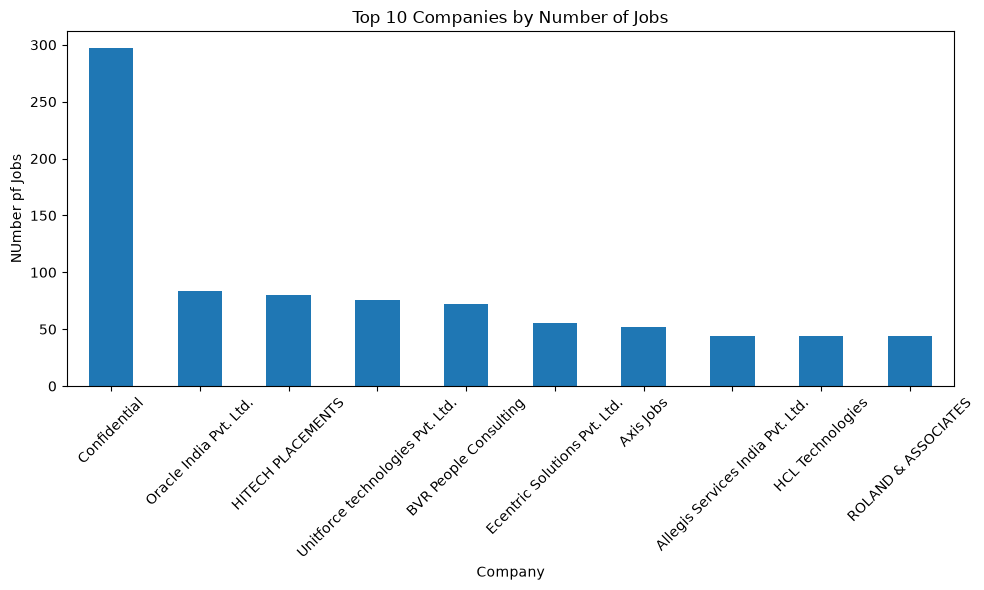

In [38]:
plt.figure(figsize=(10,6))
top_companies.plot(kind="bar")
plt.title("Top 10 Companies by Number of Jobs")
plt.xlabel("Company")
plt.ylabel("NUmber pf Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
print("Total unique companies",df["company"].nunique())

Total unique companies 3500


# Top 10 Companies


company
Confidential                        297
Oracle India Pvt. Ltd.               84
HITECH PLACEMENTS                    80
Unitforce technologies Pvt. Ltd.     76
BVR People Consulting                72
Ecentric Solutions Pvt. Ltd.         55
Axis Jobs                            52
Allegis Services India Pvt. Ltd.     44
HCL Technologies                     44
ROLAND & ASSOCIATES                  44
Name: count, dtype: int64


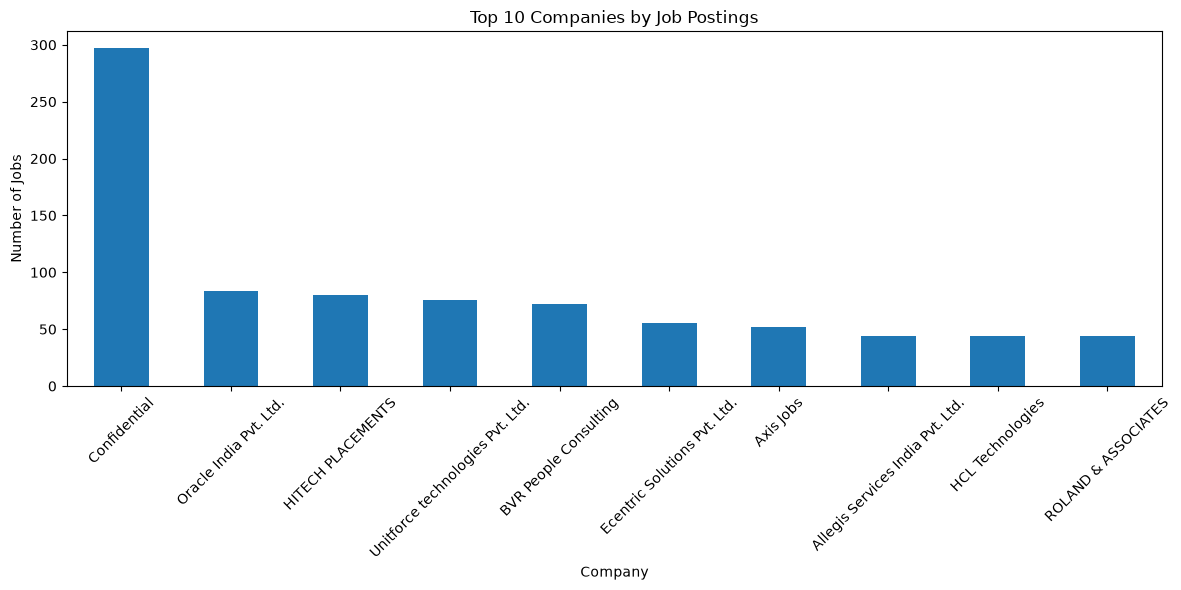

In [40]:
top_companies = df["company"].value_counts().head(10)

print(top_companies)

plt.figure(figsize=(12, 6))

top_companies.plot(kind="bar")

plt.title("Top 10 Companies by Job Postings")
plt.xlabel("Company")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

experience
2 - 7 yrs     576
3 - 8 yrs     477
2 - 5 yrs     445
5 - 10 yrs    399
3 - 5 yrs     377
0 - 5 yrs     313
4 - 9 yrs     308
1 - 3 yrs     280
2 - 4 yrs     241
3 - 6 yrs     233
0 - 1 yrs     227
1 - 5 yrs     220
0 - 3 yrs     207
1 - 6 yrs     197
0 - 2 yrs     177
1 - 2 yrs     174
4 - 6 yrs     169
1 - 4 yrs     159
5 - 7 yrs     158
4 - 8 yrs     157
Name: count, dtype: int64


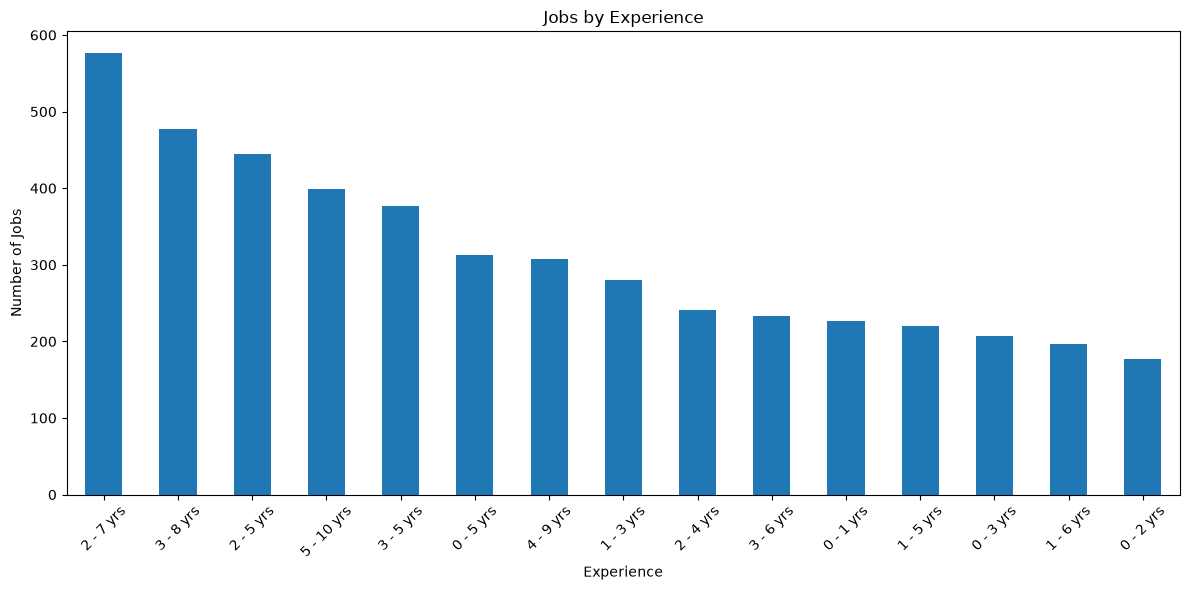

In [41]:
print(df["experience"].value_counts().head(20))

experience_counts = df["experience"].value_counts().head(15)

plt.figure(figsize=(12, 6))

experience_counts.plot(kind="bar")

plt.title("Jobs by Experience")
plt.xlabel("Experience")
plt.ylabel("Number of Jobs")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Education Analysis

In [42]:
print(df["education"].value_counts().head(15))

education
UG: Any Graduate - Any Specialization, Graduation Not Required PG:Any Postgraduate - Any Specialization, Post Graduation Not Required Doctorate:Any Doctorate - Any Specialization, Doctorate Not Required    943
UG: Any Graduate - Any Specialization PG:Any Postgraduate - Any Specialization Doctorate:Any Doctorate - Any Specialization, Doctorate Not Required                                                           801
UG: B.Tech/B.E. PG:M.Tech Doctorate:Any Doctorate - Any Specialization, Doctorate Not Required                                                                                                                674
UG: Any Graduate PG:Any Postgraduate Doctorate:Any Doctorate - Any Specialization, Doctorate Not Required                                                                                                     607
UG: B.Tech/B.E. PG:Post Graduation Not Required Doctorate:Any Doctorate - Any Specialization, Doctorate Not Required                                  

# Salary analysis

In [43]:
print(df["payrate"].value_counts().head(10))
print(df["payrate"].nunique())

payrate
Not Disclosed by Recruiter    5526
Best in the Industry            38
2,00,000 - 4,00,000 P.A         37
3,00,000 - 8,00,000 P.A         35
Best in the industry            33
Best in Industry                30
1,00,000 - 5,00,000 P.A         28
2,00,000 - 3,00,000 P.A         27
1,00,000 - 3,00,000 P.A         26
2,00,000 - 7,00,000 P.A         25
Name: count, dtype: int64
964


# skills analysis

In [44]:
print("missing skills:", df["skills"].isnull().sum())
df["skills"].head(5)
print("Unnique skill entries:", df["skills"].unique())
df["skills"] = df["skills"].fillna("")

missing skills: 229
Unnique skill entries: <StringArray>
[                                   'ITES',
                               'Marketing',
   'IT Software - Application Programming',
                                'Accounts',
                              'Production',
                                   'Sales',
                     'IT Software - Other',
                     'Executive Assistant',
                    'IT Software - Mobile',
                      'Engineering Design',
                      'Financial Services',
                                  'Hotels',
              'IT Software - QA & Testing',
                                      'HR',
                            'Supply Chain',
    'IT Software - Network Administration',
                            'Architecture',
                                   'Legal',
                        'Site Engineering',
                              'Journalism',
                                       nan,
                   

# number of skills per job

In [45]:
df["skill_count"] = (
    df["skills"]
    .fillna("")
    .apply(lambda x: len([s for s in x.split(",") if s.strip()]))
)

print(df["skill_count"].describe())

count    8000.000000
mean        0.971375
std         0.166761
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: skill_count, dtype: float64


#  Data Cleaning 

In [8]:
import pandas as pd 
import re

df = pd.read_csv('raw_jobs.csv')
print(df.shape)
print(df["jobdescription"].head())

(8000, 14)
0    Job Description   Send me Jobs like this Quali...
1    Job Description   Send me Jobs like this Quali...
2    Job Description   Send me Jobs like this - as ...
3    Job Description   Send me Jobs like this - Inv...
4    Job Description   Send me Jobs like this Pleas...
Name: jobdescription, dtype: str


In [47]:
print("missing description",
       df["jobdescription"].isnull().sum())

missing description 4


In [10]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)

    # Remove HTML
    text = re.sub(r"<.*?>", " ", text) 

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove phone numbers
    text = re.sub(r"\+?\d[\d\s().-]{8,}\d", " ", text)

    # Keep letters, numbers and spaces
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Convert to lowercase
    text = text.lower()
    return text.strip()
    


In [11]:
df["clean_description"] = df["jobdescription"].apply(clean_text)

In [50]:
print("BEFORE:")
print(df["jobdescription"].iloc[0])

print("\nAFTER:")
print(df["clean_description"].iloc[0])

BEFORE:
Job Description   Send me Jobs like this Qualifications: - == > 10th To Graduation & Any Skill: - == > Basic Computer Knowledge Job Requirement : - == > System or Laptop Type of job: - == > Full Time or Part time Languages : - == > Tamil & English. Experience : - == > Freshers & Experience payment details: - 1 form per day 5/- 10 form per day 50/- 100 form per day 500/- monthly you can earn 15000/- per month Selection Process: - == > Easy Selection Process,So What Are You Waiting For? Apply Now & Grab Best Opportunity To Make Your Carrier & To Improve Your Earing Skills. More detail contact Mr Hari 8678902528 9003010282 Salary:INR 1,50,000 - 2,25,000 P.A Industry: Media / Entertainment / Internet Functional Area: ITES , BPO , KPO , LPO , Customer Service , Operations Role Category:Other Role:Fresher Keyskills English Typing Part Time Data Entry Selection Process Desired Candidate Profile Education- UG: B.Tech/B.E. - Any Specialization PG:Any Postgraduate - Any Specialization, P

In [51]:
duplicate_count =df.duplicated().sum()
print("Duplicate records:", duplicate_count)

Duplicate records: 0


# check how much text changed

In [52]:
df["original_length"] = df["jobdescription"].fillna("").str.len()
df["clean_length"] = df["clean_description"].str.len()

print(df[["original_length","clean_length"]].describe())

       original_length  clean_length
count      8000.000000   8000.000000
mean       1906.840125   1829.140875
std        1249.388369   1191.261855
min           0.000000      0.000000
25%        1095.000000   1045.000000
50%        1516.000000   1456.000000
75%        2361.250000   2278.250000
max       22089.000000  21177.000000


In [53]:
df.loc[
    df["clean_length"].idxmin(),
    ["jobtitle", "jobdescription", "clean_description"]
]

jobtitle             1-50 of 680 Service Desk Jobs in Chennai
jobdescription                                            NaN
clean_description                                            
Name: 3768, dtype: str

# check duplicate text

In [54]:
duplicate_descriptions = df["clean_description"].duplicated().sum()
print("Duplicate descriptions:", duplicate_descriptions)

Duplicate descriptions: 133


In [55]:
duplicates = df[
    df["clean_description"].duplicated(keep=False)
].sort_values("clean_description")

duplicates[
    ["jobtitle", "clean_description"]
].head(20)

,jobtitle,clean_description
4841,1-50 of 507 Risk Analyst Jobs in Chennai,
3768,1-50 of 680 Service Desk Jobs in Chennai,
4026,1-50 of 658 .net Developer Jobs in Chennai,
4389,1-50 of 574 Asp.net Jobs in Chennai,
477,Microsoft Dynamics AX Technical Consultant,job description send me jobs like this 1 4 yea...
867,Microsoft Dynamics AX Technical Consultant,job description send me jobs like this 1 4 yea...
662,Job Openings for Platform Developer,job description send me jobs like this 1 stron...
355,Job Openings for Platform Developer for our Cl...,job description send me jobs like this 1 stron...
5232,Online Tutor - English,job description send me jobs like this ability...
5198,Online Tutor - Physics,job description send me jobs like this ability...


# Remove empty description 

In [56]:
empty_descriptions = (
    df["clean_description"].str.strip() == ""
).sum()

print("Empty descriptions:", empty_descriptions)

Empty descriptions: 4


In [57]:
df = df[ df["clean_description"].str.strip()!= ""]


In [58]:
print("final shape:", df.shape)
print("Missing clean description:", df["clean_description"].isnull().sum())
print("empty clean description:",(df["clean_description"].str.strip()=="").sum())

final shape: (7996, 17)
Missing clean description: 0
empty clean description: 0


In [59]:
print(df.columns.tolist())

['company', 'education', 'experience', 'industry', 'jobdescription', 'jobid', 'joblocation_address', 'jobtitle', 'numberofpositions', 'payrate', 'postdate', 'site_name', 'skills', 'uniq_id', 'clean_description', 'original_length', 'clean_length']


In [60]:
df.to_csv("clean_jobs.csv",index=False)
print("clean_jobs.csv create successfully!")

clean_jobs.csv create successfully!


In [14]:
skills_to_check = [
    "Python",
    "SQL",
    "Java",
    "C++",
    "C#",
    "html5",
    "css",
    "nextjs",
    "JavaScript",
    "React",
    "Angular",
    "Excel",
    "Power BI",
    "Tableau",
    "AWS",
    "Azure",
    "GCP",
    "Pandas",
    "NumPy",
    "Scikit-learn",
    "TensorFlow",
    "PyTorch",
    "Spark",
    "Hadoop",
    "Docker",
    "Kubernetes",
    "Git",
    "MongoDB",
    "PostgreSQL",
    "MySQL",
    "NLP",
    "spaCy",
    "NLTK"
]

In [15]:
description_text = (
    df["clean_description"]
    .fillna("")
    .str.lower()
)

skill_counts = {}

for skills in skills_to_check:
    count = description_text.str.contains(
        skills.lower(),
        regex=False
    ).sum()

    skill_counts[skills] = count

skill_counts

{'Python': np.int64(212),
 'SQL': np.int64(1112),
 'Java': np.int64(1315),
 'C++': np.int64(0),
 'C#': np.int64(0),
 'html5': np.int64(205),
 'css': np.int64(432),
 'nextjs': np.int64(0),
 'JavaScript': np.int64(568),
 'React': np.int64(57),
 'Angular': np.int64(192),
 'Excel': np.int64(2332),
 'Power BI': np.int64(3),
 'Tableau': np.int64(19),
 'AWS': np.int64(144),
 'Azure': np.int64(55),
 'GCP': np.int64(17),
 'Pandas': np.int64(2),
 'NumPy': np.int64(2),
 'Scikit-learn': np.int64(0),
 'TensorFlow': np.int64(1),
 'PyTorch': np.int64(0),
 'Spark': np.int64(46),
 'Hadoop': np.int64(85),
 'Docker': np.int64(8),
 'Kubernetes': np.int64(2),
 'Git': np.int64(594),
 'MongoDB': np.int64(47),
 'PostgreSQL': np.int64(21),
 'MySQL': np.int64(210),
 'NLP': np.int64(8),
 'spaCy': np.int64(0),
 'NLTK': np.int64(0)}

In [63]:
skill_check = pd.DataFrame(
    skill_counts.items(),
    columns=["Skill", "Job_Count"]
)

skill_check = skill_check.sort_values(
    "Job_Count",
    ascending=False
)

skill_check

,Skill,Job_Count
11,Excel,2332
2,Java,1315
1,SQL,1112
26,Git,594
8,JavaScript,568
6,css,432
0,Python,212
29,MySQL,210
5,html5,205
10,Angular,192


# Create Skill Taxonomy

In [1]:
import pandas as pd

skills = [
    # Programming
    ["Python", "Programming", "python3|python"],
    ["Java", "Programming", "java"],
    ["C", "Programming", "c"],
    ["C++", "Programming", "cpp|c plus plus"],
    ["C#", "Programming", "csharp|c sharp"],
    ["JavaScript", "Programming", "javascript|js"],
    ["TypeScript", "Programming", "typescript|ts"],
    ["R", "Programming", "r programming"],

    # Web Development
    ["HTML", "Web Development", "html|html5"],
    ["CSS", "Web Development", "css|css3"],
    ["React", "Web Development", "reactjs|react.js"],
    ["Angular", "Web Development", "angularjs|angular"],
    ["Vue.js", "Web Development", "vue|vuejs"],
    ["Node.js", "Web Development", "nodejs|node.js"],
    ["Express.js", "Web Development", "express|expressjs"],
    ["Next.js", "Web Development", "nextjs|next.js"],
    ["Tailwind CSS", "Web Development", "tailwind|tailwindcss"],

    # Database
    ["SQL", "Database", "sql"],
    ["MySQL", "Database", "mysql"],
    ["PostgreSQL", "Database", "postgres|postgresql"],
    ["MongoDB", "Database", "mongodb|mongo"],
    ["Oracle", "Database", "oracle database"],
    ["Redis", "Database", "redis"],

    # Data Analytics
    ["Power BI", "Data Visualization", "powerbi|power-bi"],
    ["Tableau", "Data Analytics", "tableau"],
    ["Excel", "Data Analytics", "ms excel|microsoft excel|excel"],
    ["Looker", "Data Analytics", "looker"],

    # Data Science
    ["Pandas", "Data Science", "pandas"],
    ["NumPy", "Data Science", "numpy"],
    ["Matplotlib", "Data Science", "matplotlib"],
    ["Seaborn", "Data Science", "seaborn"],
    ["SciPy", "Data Science", "scipy"],

    # Machine Learning
    ["Scikit-learn", "Machine Learning", "scikit learn|sklearn|scikit-learn"],
    ["TensorFlow", "Machine Learning", "tensorflow"],
    ["PyTorch", "Machine Learning", "pytorch"],
    ["Keras", "Machine Learning", "keras"],
    ["XGBoost", "Machine Learning", "xgboost"],
    ["LightGBM", "Machine Learning", "lightgbm"],

    # Big Data
    ["Apache Spark", "Big Data", "spark|pyspark|apache spark"],
    ["Hadoop", "Big Data", "hadoop"],
    ["Hive", "Big Data", "hive"],
    ["Kafka", "Big Data", "kafka|apache kafka"],
    ["Databricks", "Big Data", "databricks"],

    # Cloud
    ["AWS", "Cloud", "aws|amazon web services"],
    ["Azure", "Cloud", "azure|microsoft azure"],
    ["GCP", "Cloud", "gcp|google cloud"],
    ["Amazon EC2", "Cloud", "ec2|amazon ec2"],
    ["Amazon S3", "Cloud", "s3|amazon s3"],
    ["AWS Glue", "Cloud", "aws glue"],
    ["Azure Data Factory", "Cloud", "adf|azure data factory"],

    # DevOps
    ["Git", "DevOps", "git"],
    ["GitHub", "DevOps", "github"],
    ["GitLab", "DevOps", "gitlab"],
    ["Docker", "DevOps", "docker"],
    ["Kubernetes", "DevOps", "k8s|kubernetes"],
    ["Jenkins", "DevOps", "jenkins"],
    ["Terraform", "DevOps", "terraform"],
    ["Ansible", "DevOps", "ansible"],

    # AI / NLP
    ["NLP", "AI/NLP", "natural language processing"],
    ["Transformers", "AI/NLP", "transformer"],
    ["BERT", "AI/NLP", "bert"],
    ["GPT", "AI/NLP", "gpt|generative pre-trained transformer"],
    ["Hugging Face", "AI/NLP", "huggingface|hugging face"],
    ["spaCy", "AI/NLP", "spacy"],
    ["NLTK", "AI/NLP", "nltk"],
    ["LangChain", "AI/NLP", "langchain"],

    # Cybersecurity
    ["Cybersecurity", "Cybersecurity", "cyber security"],
    ["Network Security", "Cybersecurity", "network security"],
    ["Ethical Hacking", "Cybersecurity", "ethical hacking"],
    ["Penetration Testing", "Cybersecurity", "pentesting|penetration testing"],
    ["Wireshark", "Cybersecurity", "wireshark"]
]

skill_df = pd.DataFrame(
    skills,
    columns=["skill", "category", "aliases"]
)

skill_df.head(20)

,skill,category,aliases
0,Python,Programming,python3|python
1,Java,Programming,java
2,C,Programming,c
3,C++,Programming,cpp|c plus plus
4,C#,Programming,csharp|c sharp
5,JavaScript,Programming,javascript|js
6,TypeScript,Programming,typescript|ts
7,R,Programming,r programming
8,HTML,Web Development,html|html5
9,CSS,Web Development,css|css3


In [2]:
skill_df.to_csv(
    "Skill_texonomy.csv",
    index=False
)
print("skill_texonomy.csv created successfully")

skill_texonomy.csv created successfully


In [3]:
print(skill_df.shape)
print(skill_df.columns)
print(skill_df.head())
print(skill_df["category"].value_counts())

(71, 3)
Index(['skill', 'category', 'aliases'], dtype='str')
    skill     category          aliases
0  Python  Programming   python3|python
1    Java  Programming             java
2       C  Programming                c
3     C++  Programming  cpp|c plus plus
4      C#  Programming   csharp|c sharp
category
Web Development       9
Programming           8
DevOps                8
AI/NLP                8
Cloud                 7
Database              6
Machine Learning      6
Data Science          5
Big Data              5
Cybersecurity         5
Data Analytics        3
Data Visualization    1
Name: count, dtype: int64


# check duplicated

In [4]:
print("Duplicate skills:",skill_df["skill"].duplicated().sum())

Duplicate skills: 0


# Check missing values

In [5]:
print(skill_df.isnull().sum())

skill       0
category    0
aliases     0
dtype: int64


In [16]:
description_text = (
    df["clean_description"]
    .fillna("")
    .str.lower()
)

results = []

for skill in skill_df["skill"]:

    count = description_text.str.contains(
        skill.lower(),
        regex=False
    ).sum()

    results.append([skill, count])

skill_frequency = pd.DataFrame(
    results,
    columns=["skill", "job_count"]
)

skill_frequency = skill_frequency.sort_values(
    "job_count",
    ascending=False
)

skill_frequency.head(20)

,skill,job_count
2,C,7996
7,R,7996
25,Excel,2332
1,Java,1315
17,SQL,1112
21,Oracle,618
50,Git,594
5,JavaScript,568
8,HTML,559
9,CSS,432


In [17]:
import pandas as pd
taxonomy = pd.read_csv("skill_texonomy.csv")

new_skills = pd.DataFrame([
    ["Basic Computer Knowledge", "Computer", "basic computer, computer knowledge"],
    ["Computer Fundamentals", "Computer", "computer fundamentals"],
    ["MS Office", "Office Tools", "microsoft office, ms office"],
    ["MS Word", "Office Tools", "microsoft word, ms word"],
    ["PowerPoint", "Office Tools", "microsoft powerpoint, ms powerpoint"],
    ["Internet", "Computer", "internet knowledge, internet"],
    ["Email Handling", "Computer", "email handling, email management"],
    ["Data Entry", "Data Entry", "dataentry, data entry operator"],
    ["Typing", "Data Entry", "typing, english typing"],
    ["English Typing", "Data Entry", "english typing"],
    ["Data Collection", "Data Entry", "data collection"],
    ["Data Processing", "Data Entry", "data processing"],
    ["Customer Service", "Customer Service", "customer support, customer care"],
    ["Customer Support", "Customer Service", "customer support"],
    ["BPO", "BPO", "business process outsourcing"],
    ["KPO", "BPO", "knowledge process outsourcing"],
    ["Call Center", "BPO", "call centre, call center"],
    ["Operations", "Operations", "operations management"],
    ["English", "Language", "english language"],
    ["Tamil", "Language", "tamil language"],
    ["Hindi", "Language", "hindi language"],
    ["Communication", "Soft Skill", "communication skills"],
    ["php", "Programming", "PHP"],
    ["Machine Learning", "Machine Learning", "ml"],
    ["Deep Learning", "Machine Learning", "deep learning"],
    ["Data Science", "Data Science", "data science"],
    ["Natural Language Processing", "NLP", "nlp"],
    ["Computer Vision", "Machine Learning", "cv, computer vision"],
    ["Artificial Intelligence", "AI", "ai"],
    ["Data Analysis", "Data Analytics", "data analysis"],
], columns=["skill", "category", "aliases"])

taxonomy = pd.concat(
    [taxonomy, new_skills],
    ignore_index=True
)

taxonomy = taxonomy.drop_duplicates(
    subset=["skill"],
    keep="first"
)

taxonomy.to_csv(
    "Skill_taxonomy.csv",
    index=False
)

print("Updated taxonomy shape:", taxonomy.shape)
print(taxonomy.tail(25))

Updated taxonomy shape: (101, 3)
                           skill          category  \
76                      Internet          Computer   
77                Email Handling          Computer   
78                    Data Entry        Data Entry   
79                        Typing        Data Entry   
80                English Typing        Data Entry   
81               Data Collection        Data Entry   
82               Data Processing        Data Entry   
83              Customer Service  Customer Service   
84              Customer Support  Customer Service   
85                           BPO               BPO   
86                           KPO               BPO   
87                   Call Center               BPO   
88                    Operations        Operations   
89                       English          Language   
90                         Tamil          Language   
91                         Hindi          Language   
92                 Communication        Soft Skil